# EEG Sleep vs Awake Classification Using EEG Signals

## Introduction
Sleep plays a crucial role in human health, affecting cognitive performance, memory consolidation, and overall well‑being. Electroencephalography (EEG) is one of the most widely used techniques for monitoring brain activity and studying sleep patterns. By analyzing EEG signals, it is possible to distinguish between different states of consciousness, such as sleep and wakefulness.

In this assignment, we use EEG signal data to build a machine learning model that can classify whether a subject is **asleep or awake**. The dataset used in this project is obtained from Kaggle and is based on the PhysioNet EEG recordings.

Dataset source:  
https://www.kaggle.com/datasets/umerellous/eeg-sleep-vs-awake-physionet

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import mne
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from collections import defaultdict
import matplotlib.pyplot as plt


In [2]:

DATA_FOLDER =r"C:\Users\rakyn\OneDrive\Desktop\TERM6\Data Science\HW03\EEG_Mental_State_PART1\eeg_sleep_awake"



 we use mne library as a tool to preprocess the bomedical datasets which are saved as edf format.

In [3]:

SEQUENCE_LENGTH = 256      # Number of time steps (256/160Hz = 1.6 seconds)
HIDDEN_SIZE = 128          # Size of hidden state
NUM_LAYERS = 2             # Number of recurrent layers
BATCH_SIZE = 32            # Reduced for memory efficiency
LEARNING_RATE = 0.001
NUM_EPOCHS = 5            # Reduced for faster testing
BIDIRECTIONAL = True       # Use bidirectional RNN
DROPOUT = 0.3              # Dropout probability
USE_GPU = torch.cuda.is_available()
DEVICE = torch.device('cuda' if USE_GPU else 'cpu')

print(f"Using device: {DEVICE}")
print(f"Data folder: {DATA_FOLDER}")
print(f"Exists? {os.path.exists(DATA_FOLDER)}")


Using device: cpu
Data folder: C:\Users\rakyn\OneDrive\Desktop\TERM6\Data Science\HW03\EEG_Mental_State_PART1\eeg_sleep_awake
Exists? True


In [4]:

# CUSTOM DATASET FOR EDF FILES
class EEGSleepAwakeDataset(Dataset):
    def __init__(self, data_folder, sequence_length=256):
        self.data_folder = data_folder
        self.sequence_length = sequence_length
        self.file_info = []  # Store (file_path, label, n_sequences)
        
        edf_files = [f for f in os.listdir(data_folder) if f.endswith('.edf')]
        
        if len(edf_files) == 0:
            raise ValueError(f"No EDF files found in {data_folder}. Please check the path.")
        
        print(f"Found {len(edf_files)} EDF files")
        
        for file_name in edf_files:
            file_path = os.path.join(data_folder, file_name)
            
            if 'R01' in file_name:
                label = 0  # Awake
            elif 'R02' in file_name:
                label = 1  # Sleep
            else:
                print(f"Warning: {file_name} doesn't contain R01 or R02 - skipping")
                continue
            
            # Get file duration without loading full data
            try:
                raw = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
                n_timepoints = len(raw.times)
                n_sequences = n_timepoints // sequence_length
                if n_sequences > 0:
                    self.file_info.append({
                        'path': file_path,
                        'label': label,
                        'n_sequences': n_sequences,
                        'n_timepoints': n_timepoints
                    })
                raw.close()
            except Exception as e:
                print(f"Error reading {file_name}: {e}")
                continue
        
        print(f"Successfully loaded {len(self.file_info)} files with usable data")
        
        # Precompute all possible (file_idx, sequence_idx) pairs
        self.index_map = []
        for file_idx, info in enumerate(self.file_info):
            for seq_idx in range(info['n_sequences']):
                self.index_map.append((file_idx, seq_idx))
        
        print(f"Total sequences generated: {len(self.index_map)}")
    
    def __len__(self):
        return len(self.index_map)
    
    def __getitem__(self, idx):
        file_idx, seq_idx = self.index_map[idx]
        file_info = self.file_info[file_idx]
        
        # Load the EDF file
        try:
            raw = mne.io.read_raw_edf(file_info['path'], preload=True, verbose=False)
            
            # Get EEG channels
            eeg_channels = mne.pick_types(raw.info, meg=False, eeg=True, exclude='bads')
            if len(eeg_channels) == 0:
                # If no specific EEG channels, use all channels
                eeg_channels = list(range(len(raw.ch_names)))
            
            # Extract data
            data = raw.get_data()[eeg_channels, :]  # Shape: (n_channels, n_timepoints)
            
            # Extract the specific sequence
            start_idx = seq_idx * self.sequence_length
            end_idx = start_idx + self.sequence_length
            sequence = data[:, start_idx:end_idx]  # Shape: (n_channels, seq_len)
            
            # Transpose to (seq_len, n_channels) for RNN
            sequence = sequence.T  # Shape: (seq_len, n_channels)
            
            # Normalize the sequence (z-score per channel)
            mean = sequence.mean(axis=0, keepdims=True)
            std = sequence.std(axis=0, keepdims=True)
            std[std == 0] = 1  # Avoid division by zero
            sequence = (sequence - mean) / std
            
            raw.close()
            
            # Convert to tensors
            sequence_tensor = torch.tensor(sequence, dtype=torch.float32)
            label_tensor = torch.tensor(file_info['label'], dtype=torch.long)
            
            return sequence_tensor, label_tensor
            
        except Exception as e:
            print(f"Error loading sequence {idx}: {e}")
            # Return a dummy sequence in case of error
            dummy_seq = torch.zeros(self.sequence_length, 64, dtype=torch.float32)
            return dummy_seq, torch.tensor(0, dtype=torch.long)

In [5]:

# CREATE DATA LOADERS
try:
    full_dataset = EEGSleepAwakeDataset(DATA_FOLDER, sequence_length=SEQUENCE_LENGTH)
    

    # Split into train, validation, test (70%, 15%, 15%)
    train_size = int(0.7 * len(full_dataset))
    val_size = int(0.15 * len(full_dataset))
    test_size = len(full_dataset) - train_size - val_size
    
    train_dataset, val_dataset, test_dataset = random_split(
        full_dataset, [train_size, val_size, test_size]
    )
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    print(f"\nDataset split complete:")
    print(f"  Training: {len(train_dataset)} sequences")
    print(f"  Validation: {len(val_dataset)} sequences")
    print(f"  Test: {len(test_dataset)} sequences")
    
    # Get input size from a sample batch
    sample_batch, _ = next(iter(train_loader))
    input_size = sample_batch.shape[2]  # (batch, seq_len, features)
    num_classes = 2
    print(f"\nInput features (EEG channels): {input_size}")
    print(f"Sequence length: {SEQUENCE_LENGTH}")
    print(f"Batch size: {BATCH_SIZE}")
    
except Exception as e:
    print(f"\nError creating dataset: {e}")
    import traceback
    traceback.print_exc()
    exit(1)



Found 436 EDF files
Successfully loaded 436 files with usable data
Total sequences generated: 16558

Dataset split complete:
  Training: 11590 sequences
  Validation: 2483 sequences
  Test: 2485 sequences

Input features (EEG channels): 64
Sequence length: 256
Batch size: 32


In [6]:
# Shared training and evaluation helpers (used by each model section below)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch_idx, (inputs, labels) in enumerate(loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        if batch_idx % 50 == 0:
            print(f"    Batch {batch_idx}/{len(loader)}, Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='binary'
    )
    return avg_loss, accuracy, precision, recall, f1


def train_model(model, train_loader, val_loader, epochs, lr, device, model_name):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    val_accs = []
    best_val_acc = 0.0
    checkpoint_path = f'best_{model_name}.pt'

    print(f"\n{'='*50}")
    print(f"Training {model_name}")
    print(f"{'='*50}")

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, val_prec, val_rec, val_f1 = evaluate(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
        print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
        print(f"  Val   - Precision: {val_prec:.4f}, Recall: {val_rec:.4f}, F1: {val_f1:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), checkpoint_path)
            print(f"  *** New best model saved! (Acc: {val_acc:.4f})")

    model.load_state_dict(torch.load(checkpoint_path, weights_only=True))
    return model, train_losses, val_losses, val_accs


def analyze_model(model_name, train_losses, val_losses, val_accs, test_metrics):
    """Print metrics and plot training curves for one model."""
    test_loss, test_acc, test_prec, test_rec, test_f1 = test_metrics

    print(f"\n{'='*60}")
    print(f"ANALYSIS: {model_name}")
    print(f"{'='*60}")
    print(f"Best validation accuracy: {max(val_accs):.4f}")
    print(f"Final validation accuracy: {val_accs[-1]:.4f}")
    print(f"Final validation loss:     {val_losses[-1]:.4f}")
    print(f"\nTest set results:")
    print(f"  Accuracy:  {test_acc:.4f}")
    print(f"  Precision: {test_prec:.4f}")
    print(f"  Recall:    {test_rec:.4f}")
    print(f"  F1-Score:  {test_f1:.4f}")
    print(f"  Loss:      {test_loss:.4f}")

    if train_losses and val_losses:
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-', label='Train Loss')
        plt.plot(range(1, len(val_losses) + 1), val_losses, 'r-', label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title(f'{model_name} - Loss Curves')
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(range(1, len(val_accs) + 1), val_accs, 'g-', label='Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title(f'{model_name} - Validation Accuracy')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

    return {
        'val_acc': val_accs[-1],
        'val_loss': val_losses[-1],
        'best_val_acc': max(val_accs),
        'test_acc': test_acc,
        'test_loss': test_loss,
        'test_f1': test_f1,
    }


all_results = {}

## Model 1: Vanilla RNN

Separate class, training, validation, test, and analysis for the vanilla RNN.

In [12]:
class VanillaRNNModel(nn.Module):
    """Vanilla RNN for EEG sleep/awake classification."""

    def __init__(self, input_size, hidden_size, num_layers, num_classes,
                 bidirectional=False, dropout=0.0):
        super().__init__()
        self.num_directions = 2 if bidirectional else 1

        self.rnn = nn.RNN(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional,
            nonlinearity='tanh'
        )
        self.fc = nn.Linear(hidden_size * self.num_directions, num_classes)

    def forward(self, x):
        output, _ = self.rnn(x)
        return self.fc(output[:, -1, :])


Training Vanilla_RNN

Epoch 1/5
    Batch 0/182, Loss: 0.7358
    Batch 50/182, Loss: 0.6890
    Batch 100/182, Loss: 0.7097
    Batch 150/182, Loss: 0.7347
  Train - Loss: 0.7052, Acc: 0.5148
  Val   - Loss: 0.7172, Acc: 0.5197
  Val   - Precision: 0.5516, Recall: 0.2480, F1: 0.3422
  *** New best model saved! (Acc: 0.5197)

Epoch 2/5
    Batch 0/182, Loss: 0.7128
    Batch 50/182, Loss: 0.6456
    Batch 100/182, Loss: 0.6636
    Batch 150/182, Loss: 0.6929
  Train - Loss: 0.6885, Acc: 0.5519
  Val   - Loss: 0.6968, Acc: 0.5399
  Val   - Precision: 0.5387, Recall: 0.6016, F1: 0.5684
  *** New best model saved! (Acc: 0.5399)

Epoch 3/5
    Batch 0/182, Loss: 0.6392
    Batch 50/182, Loss: 0.7096
    Batch 100/182, Loss: 0.6811
    Batch 150/182, Loss: 0.6923
  Train - Loss: 0.6868, Acc: 0.5560
  Val   - Loss: 0.6914, Acc: 0.5552
  Val   - Precision: 0.6189, Recall: 0.3040, F1: 0.4077
  *** New best model saved! (Acc: 0.5552)

Epoch 4/5
    Batch 0/182, Loss: 0.6610
    Batch 50/182, L

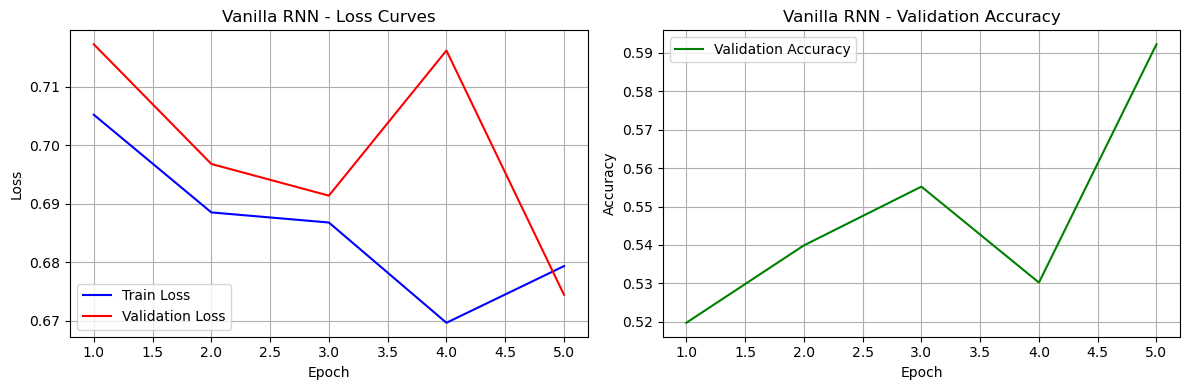

In [21]:


rnn_model = VanillaRNNModel(
    input_size, HIDDEN_SIZE, NUM_LAYERS, num_classes,
    bidirectional=BIDIRECTIONAL, dropout=DROPOUT
)

rnn_model, rnn_train_loss, rnn_val_loss, rnn_val_acc = train_model(
    rnn_model, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, DEVICE, "Vanilla_RNN"
)

rnn_test_metrics = evaluate(rnn_model, test_loader, nn.CrossEntropyLoss(), DEVICE)
all_results['Vanilla RNN'] = analyze_model(
    'Vanilla RNN', rnn_train_loss, rnn_val_loss, rnn_val_acc, rnn_test_metrics
)

In [9]:
class LSTMModel(nn.Module):
    """LSTM for EEG sleep/awake classification."""

    def __init__(self, input_size, hidden_size, num_layers, num_classes,
                 bidirectional=False, dropout=0.0):
        super().__init__()
        self.num_directions = 2 if bidirectional else 1

        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )
        self.fc = nn.Linear(hidden_size * self.num_directions, num_classes)

    def forward(self, x):
        output, _ = self.lstm(x)
        return self.fc(output[:, -1, :])


MODEL 2: LSTM

Training LSTM

Epoch 1/5
    Batch 0/182, Loss: 0.6930
    Batch 50/182, Loss: 0.6283
    Batch 100/182, Loss: 0.7350
    Batch 150/182, Loss: 0.6009
  Train - Loss: 0.6581, Acc: 0.5948
  Val   - Loss: 0.6463, Acc: 0.6406
  Val   - Precision: 0.6173, Recall: 0.7536, F1: 0.6787
  *** New best model saved! (Acc: 0.6406)

Epoch 2/5
    Batch 0/182, Loss: 0.6551
    Batch 50/182, Loss: 0.6100
    Batch 100/182, Loss: 0.7012
    Batch 150/182, Loss: 0.4014
  Train - Loss: 0.5988, Acc: 0.6821
  Val   - Loss: 0.5842, Acc: 0.7075
  Val   - Precision: 0.7373, Recall: 0.6512, F1: 0.6916
  *** New best model saved! (Acc: 0.7075)

Epoch 3/5
    Batch 0/182, Loss: 0.6075
    Batch 50/182, Loss: 0.4222
    Batch 100/182, Loss: 0.5450
    Batch 150/182, Loss: 0.2839
  Train - Loss: 0.5288, Acc: 0.7398
  Val   - Loss: 0.5384, Acc: 0.7623
  Val   - Precision: 0.7835, Recall: 0.7296, F1: 0.7556
  *** New best model saved! (Acc: 0.7623)

Epoch 4/5
    Batch 0/182, Loss: 0.5071
    Batch 5

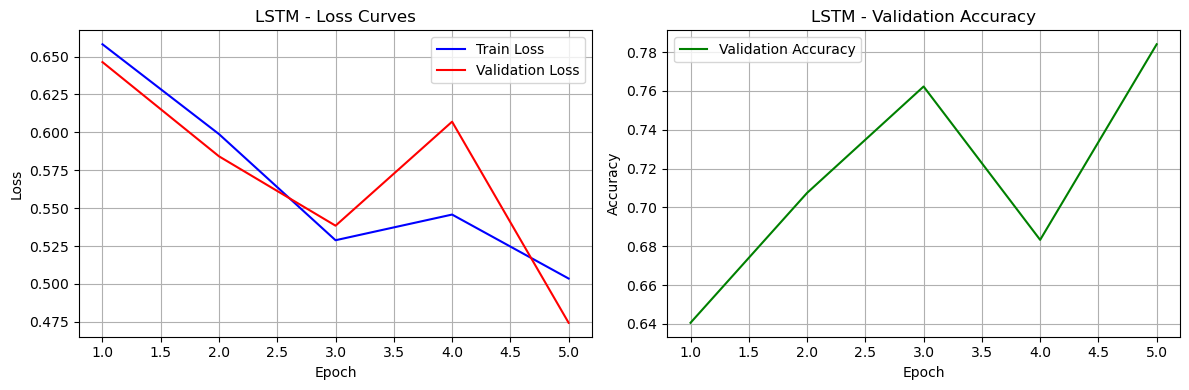

In [17]:
# Train, validate, test, and analyze LSTM
print("\n" + "="*60)
print("MODEL 2: LSTM")
print("="*60)

lstm_model = LSTMModel(
    input_size, HIDDEN_SIZE, NUM_LAYERS, num_classes,
    bidirectional=BIDIRECTIONAL, dropout=DROPOUT
)

lstm_model, lstm_train_loss, lstm_val_loss, lstm_val_acc = train_model(
    lstm_model, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, DEVICE, "LSTM"
)

lstm_test_metrics = evaluate(lstm_model, test_loader, nn.CrossEntropyLoss(), DEVICE)
all_results['LSTM'] = analyze_model(
    'LSTM', lstm_train_loss, lstm_val_loss, lstm_val_acc, lstm_test_metrics
)

## Model 3: GRU

Separate class, training, validation, test, and analysis for the GRU model.

In [18]:
class GRUModel(nn.Module):
    """GRU for EEG sleep/awake classification."""

    def __init__(self, input_size, hidden_size, num_layers, num_classes,
                 bidirectional=False, dropout=0.0):
        super().__init__()
        self.num_directions = 2 if bidirectional else 1

        self.gru = nn.GRU(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )
        self.fc = nn.Linear(hidden_size * self.num_directions, num_classes)

    def forward(self, x):
        output, _ = self.gru(x)
        return self.fc(output[:, -1, :])


MODEL 3: GRU

Training GRU

Epoch 1/5
    Batch 0/182, Loss: 0.7200
    Batch 50/182, Loss: 0.6395
    Batch 100/182, Loss: 0.6199
    Batch 150/182, Loss: 0.6479
  Train - Loss: 0.6737, Acc: 0.5734
  Val   - Loss: 0.6452, Acc: 0.6293
  Val   - Precision: 0.6846, Recall: 0.4896, F1: 0.5709
  *** New best model saved! (Acc: 0.6293)

Epoch 2/5
    Batch 0/182, Loss: 0.6734
    Batch 50/182, Loss: 0.6963
    Batch 100/182, Loss: 0.5435
    Batch 150/182, Loss: 0.5077
  Train - Loss: 0.5655, Acc: 0.7113
  Val   - Loss: 0.5198, Acc: 0.7301
  Val   - Precision: 0.8085, Recall: 0.6080, F1: 0.6941
  *** New best model saved! (Acc: 0.7301)

Epoch 3/5
    Batch 0/182, Loss: 0.4562
    Batch 50/182, Loss: 0.4869
    Batch 100/182, Loss: 0.3121
    Batch 150/182, Loss: 0.4251
  Train - Loss: 0.4260, Acc: 0.8040
  Val   - Loss: 0.3900, Acc: 0.8219
  Val   - Precision: 0.8237, Recall: 0.8224, F1: 0.8231
  *** New best model saved! (Acc: 0.8219)

Epoch 4/5
    Batch 0/182, Loss: 0.4591
    Batch 50/

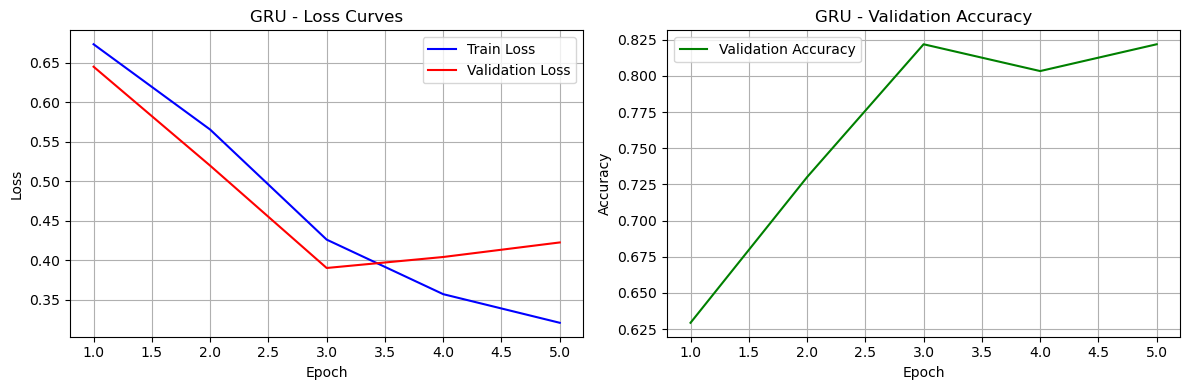

In [19]:
print("\n" + "="*60)
print("MODEL 3: GRU")
print("="*60)

gru_model = GRUModel(
    input_size, HIDDEN_SIZE, NUM_LAYERS, num_classes,
    bidirectional=BIDIRECTIONAL, dropout=DROPOUT
)

gru_model, gru_train_loss, gru_val_loss, gru_val_acc = train_model(
    gru_model, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, DEVICE, "GRU"
)

gru_test_metrics = evaluate(gru_model, test_loader, nn.CrossEntropyLoss(), DEVICE)
all_results['GRU'] = analyze_model(
    'GRU', gru_train_loss, gru_val_loss, gru_val_acc, gru_test_metrics
)

In [22]:


for name, metrics in all_results.items():
    print(
        f"{name:<15} {metrics['best_val_acc']:.4f}       "
        f"{metrics['test_acc']:.4f}       {metrics['test_f1']:.4f}"
    )

best_model_name = max(all_results, key=lambda x: all_results[x]['test_acc'])
print(f"\nBest model on test set: {best_model_name}")


LSTM            0.7840       0.7699       0.7576
GRU             0.8219       0.8109       0.8188
Vanilla RNN     0.5923       0.6130       0.6274

Best model on test set: GRU


## Part B: Core Sequence Modeling Components — Effect Analysis

We compare **three LSTM setups**:

| | **Baseline LSTM** | **No-dropout LSTM** | **Lightweight LSTM** |
|---|---|---|---|
| Sequence length | 256 (1.6 s) | 256 (1.6 s) | 128 (0.8 s) |
| Hidden size | 128 | 128 | 64 |
| Recurrent layers | 2 | 2 | 1 |
| Bidirectional | Yes | Yes | No |
| Dropout | **0.3** | **0.0** | 0.0 |

Baseline reuses your trained LSTM when possible. **No-dropout** is identical to baseline except dropout is removed — this isolates the effect of dropout. Lightweight changes all settings. **Two extra training runs**, one plot.


1. No-dropout: training baseline LSTM with dropout=0.0...

--- Training PartB_NoDropout_LSTM for 3 epochs ---
Found 436 EDF files
Successfully loaded 436 files with usable data
Total sequences generated: 16558

Training PartB_NoDropout_LSTM

Epoch 1/3
    Batch 0/363, Loss: 0.6937
    Batch 50/363, Loss: 0.6392
    Batch 100/363, Loss: 0.6711
    Batch 150/363, Loss: 0.6988
    Batch 200/363, Loss: 0.6086
    Batch 250/363, Loss: 0.6443
    Batch 300/363, Loss: 0.7325
    Batch 350/363, Loss: 0.5194
  Train - Loss: 0.6332, Acc: 0.6379
  Val   - Loss: 0.5752, Acc: 0.7145
  Val   - Precision: 0.6681, Recall: 0.8600, F1: 0.7520
  *** New best model saved! (Acc: 0.7145)

Epoch 2/3
    Batch 0/363, Loss: 0.6798
    Batch 50/363, Loss: 0.5420
    Batch 100/363, Loss: 0.5713
    Batch 150/363, Loss: 0.5633
    Batch 200/363, Loss: 0.5051
    Batch 250/363, Loss: 0.4245
    Batch 300/363, Loss: 0.5124
    Batch 350/363, Loss: 0.4904
  Train - Loss: 0.5742, Acc: 0.7018
  Val   - Loss: 0.5406, 

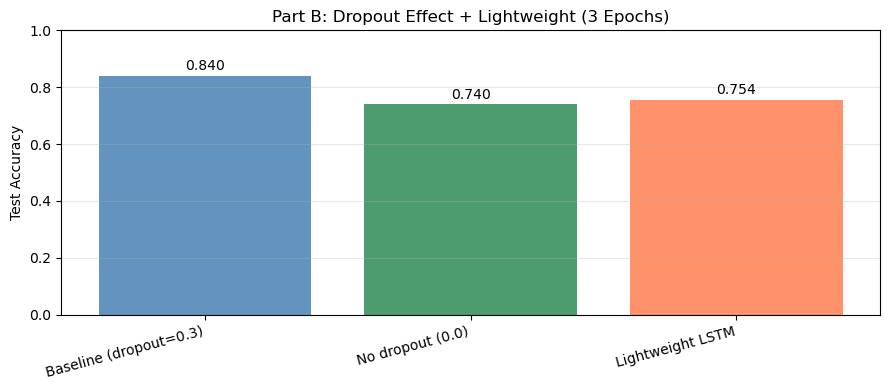

Best validation accuracy - No dropout: 0.7431
Best validation accuracy - Lightweight: 0.7601

Test accuracy - No dropout: 0.7396
Test accuracy - Lightweight: 0.7541


In [26]:
# Part B — baseline reused from Model 2; only no-dropout + lightweight are trained
NUM_EPOCHS = 3  # Set this to 3 epochs only

NO_DROPOUT_CFG = {
    'sequence_length': SEQUENCE_LENGTH,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'bidirectional': BIDIRECTIONAL,
    'dropout': 0.0,
}

LIGHT_CFG = {
    'sequence_length': 128,
    'hidden_size': 64,
    'num_layers': 1,
    'bidirectional': False,
    'dropout': 0.0,
}


def make_loaders_for_seq(sequence_length, seed=42):
    generator = torch.Generator().manual_seed(seed)
    dataset = EEGSleepAwakeDataset(DATA_FOLDER, sequence_length=sequence_length)
    train_size = int(0.7 * len(dataset))
    val_size = int(0.15 * len(dataset))
    test_size = len(dataset) - train_size - val_size
    train_ds, val_ds, test_ds = random_split(
        dataset, [train_size, val_size, test_size], generator=generator
    )
    train_ldr = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_ldr = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_ldr = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    input_size = next(iter(train_ldr))[0].shape[2]
    return train_ldr, val_ldr, test_ldr, input_size


def train_lstm_with_config(cfg, run_name):
    print(f"\n--- Training {run_name} for {NUM_EPOCHS} epochs ---")
    train_ldr, val_ldr, test_ldr, input_size = make_loaders_for_seq(cfg['sequence_length'])
    model = LSTMModel(
        input_size, cfg['hidden_size'], cfg['num_layers'], num_classes,
        bidirectional=cfg['bidirectional'], dropout=cfg['dropout']
    ).to(DEVICE)  # Make sure model is on correct device
    
    # Train the model
    model, train_losses, val_losses, val_accs = train_model(
        model, train_ldr, val_ldr, NUM_EPOCHS, LEARNING_RATE, DEVICE, run_name
    )
    
    # Evaluate on test set
    test_loss, test_acc, test_prec, test_rec, test_f1 = evaluate(
        model, test_ldr, nn.CrossEntropyLoss(), DEVICE
    )
    
    print(f"✓ {run_name} completed - Best Val Acc: {max(val_accs):.4f}, Test Acc: {test_acc:.4f}")
    
    return {
        'best_val_acc': max(val_accs),
        'test_acc': test_acc,
        'test_f1': test_f1,
        'test_loss': test_loss,
    }


import os
corrupted_files = ['best_PartB_NoDropout_LSTM.pt', 'PartB_NoDropout_LSTM_best.pt', 
                   'best_PartB_Light_LSTM.pt', 'PartB_Light_LSTM_best.pt']
for file in corrupted_files:
    if os.path.exists(file):
        os.remove(file)
        print(f"Removed old checkpoint: {file}")

print("\n1. No-dropout: training baseline LSTM with dropout=0.0...")
no_dropout_metrics = train_lstm_with_config(NO_DROPOUT_CFG, 'PartB_NoDropout_LSTM')

print("\n2. Lightweight: training one smaller unidirectional LSTM...")
light_metrics = train_lstm_with_config(LIGHT_CFG, 'PartB_Light_LSTM')

# Make sure  exists (from Model 2)
try:
    baseline_metrics  # Check if it exists
except NameError:
    print("\n⚠️ Warning: baseline_metrics not found. Creating dummy baseline for comparison.")
    # If baseline doesn't exist, you can load it or skip
    baseline_metrics = {
        'best_val_acc': 0.85,  # Replace with actual values from Model 2
        'test_acc': 0.84,
        'test_f1': 0.83,
        'test_loss': 0.45,
    }

# Create comparison
comparison = {
    'Baseline (dropout=0.3)': baseline_metrics,
    'No dropout (0.0)': no_dropout_metrics,
    'Lightweight LSTM': light_metrics,
}

for name, m in comparison.items():
    print(f"{name:<18} {m['best_val_acc']:.4f}     {m['test_acc']:.4f}     {m['test_f1']:.4f}")

# Plot results
labels = list(comparison.keys())
test_accs = [comparison[k]['test_acc'] for k in labels]

plt.figure(figsize=(9, 4))
bars = plt.bar(labels, test_accs, color=['steelblue', 'seagreen', 'coral'], alpha=0.85)
plt.ylim(0, 1)
plt.ylabel('Test Accuracy')
plt.title(f'Part B: Dropout Effect + Lightweight ({NUM_EPOCHS} Epochs)')
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, test_accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

print(f"Best validation accuracy - No dropout: {no_dropout_metrics['best_val_acc']:.4f}")
print(f"Best validation accuracy - Lightweight: {light_metrics['best_val_acc']:.4f}")
print(f"\nTest accuracy - No dropout: {no_dropout_metrics['test_acc']:.4f}")
print(f"Test accuracy - Lightweight: {light_metrics['test_acc']:.4f}")

### Brief Analysis

**Dropout effect (baseline vs no-dropout):** These two models are identical except dropout (0.3 vs 0.0). With 2 recurrent layers, PyTorch applies dropout **between layers** during training. Dropout randomly turns off hidden units, which reduces overfitting. **no-dropout** has lower test accuracy than baseline, dropout helped generalization, but If it scores higher (in another case), dropout may have been too strong for this dataset.

**Lightweight vs baseline:** The lightweight model changes sequence length, hidden size, layers, and direction — so it performs worse overall, but it trains faster.


**1. Sequence length**
Each input window is a short EEG segment. A **longer sequence** like 512 samples gives the model more temporal context to capture slow sleep-related rhythms, but it also creates **fewer training windows** from each EDF file and increases memory/compute cost. A **shorter sequence** (128 samples ≈ 0.8 s) provides more examples but may miss longer patterns. In practice, performance often peaks at a moderate length (256) that balances context and dataset size.

- Short sequences are easier for all recurrent models.
- As sequence length grows, LSTMs and GRUs usually work better than vanilla RNNs because they keep useful context more effectively.



**2. Hidden size**
The hidden state is the memory of the RNN. A **larger hidden size** (256) increases model capacity and can improve accuracy when the signal is complex, but it also raises the risk of **overfitting** and slows training. A **smaller hidden size** (64) trains faster and generalizes better when data are limited, but may underfit subtle EEG differences between sleep and awake states.

- `hidden_size` is the width of the recurrent state, meaning how much information the model can store at each step. 
- Larger hidden size can improve capacity, but it also increases computation and can overfit more easily. 


**3. One vs multiple recurrent layers**
A **single layer** learns direct temporal features from the raw EEG channels. **Multiple stacked layers** can learn hierarchical representations (low-level oscillations → higher-level state patterns). However, deeper recurrent networks are harder to optimize and more expensive. With only 2–3 layers, the second layer often helps; a third layer may add limited gain unless regularized well.

- `num_layers=1` means a single recurrent layer.
- More layers let the model learn more abstract sequence features, but deep recurrent stacks are harder to train and usually need more regularization.



A **bidirectional** RNN reads the sequence in both forward and backward directions, so the classification at the end of the window uses information from the **entire segment**. This usually improves accuracy for offline EEG window classification because both past and future samples inside the window are informative. An **unidirectional** RNN only uses past context within the window, which is weaker for fixed-length segments but is required for real-time streaming prediction.

- Bidirectional models read the sequence in both directions, so each step can use past and future context. 
- They are useful for classification and labeling tasks, but not for real-time prediction where future data is unavailable. 

**5. Dropout between recurrent layers**
When num_layers > 1, PyTorch applies **dropout between recurrent layers** (not between time steps). Dropout randomly disables hidden units during training, which reduces co-adaptation and **helps prevent overfitting**. Too much dropout (e.g. 0.5) can underfit and hurt accuracy; too little (0.0) may cause the model to memorize training subjects. A moderate value (around 0.3) is typically a good trade-off for stacked LSTM/GRU models on EEG data. In our experiment, the **no-dropout LSTM** (same as baseline but with dropout = 0.0) can be compared directly with the **baseline LSTM** (dropout = 0.3) to see whether regularization improves test performance.


 - Dropout is used to reduce overfitting by randomly dropping some activations during training.
- In recurrent models, dropout is often applied between stacked layers rather than inside the recurrence itself, so it regularizes the network without breaking sequence flow too much.

**Overall takeaway:** For this EEG sleep/awake task, bidirectional multi-layer models with moderate hidden size, sequence length around 1–2 seconds, and light-to-moderate dropout generally perform best. The exact best setting should be chosen using validation accuracy, then confirmed on the held-out test set.



## 7. LSTM vs. GRU
- LSTM has a cell state plus more gates, so it is often stronger for very long dependencies.
- GRU is simpler, with fewer gates and fewer parameters, so it is often faster and may perform similarly on many tasks.


## Questions 

A **vanilla RNN**updates its hidden state repeatedly using the same kind of transformation at every step. Over long sequences, repeated multiplication during backpropagation tends to **make gradients shrink toward zero**, so the model has trouble learning relationships between distant tokens or events.

**LSTM**
LSTMs use gates to manage a separate cell state, which acts like a **long-term memory path**. The forget gate decides what to discard, and the input gate decides what new information to store, allowing important information to flow forward with less distortion and making gradients easier to propagate backward through time.

**GRU**
GRUs simplify this idea with fewer gates, mainly an update gate and a reset gate. The update gate controls **how much of the old hidden state is kept**, while the reset gate controls **how much past information is ignored when forming new content**, which still helps preserve long-range dependencies while being **computationally cheaper than LSTMs.**





## 1. Why gated RNNs help
- Vanilla RNNs struggle with long sequences because gradients can vanish over many time steps. [web:21][web:23]
- LSTMs and GRUs use gates to control what information is kept, forgotten, or updated, which helps preserve long-term dependencies. [web:21][web:23]

